# 3.1 Variable Properties And Units

Layer properties can be constants, Pint quantities, `xarray.DataArray` values, file-backed properties, or expression-backed properties. This notebook uses `xarray` so the property varies with depth inside one layer.

By the end, you should be able to choose between constants, Pint quantities, and `xarray` properties, then verify a variable model before spending solver time.


## How To Read This Tutorial

This notebook moves beyond constant layered properties while keeping the geometry simple. The story is: define a property with physical units, inspect it as ordinary `xarray`, sample it onto a regular grid for sanity checks, and only then send it to the solver.

The unique capability here is that FrequenSolve can keep high-level model intent in Python instead of forcing every model to begin as a uniform raster. Use variable properties when the geology is still naturally described as layers plus continuous trends.

## Design Notes

Layer properties can be authored at several levels of complexity. Start with constants for flat layered examples, move to `xarray.DataArray` when a property varies along one or more coordinates, and use expression- or file-backed forms when the model is generated outside a notebook.

| Property form | Best use | Unit handling |
| --- | --- | --- |
| Constant number | Quick examples in the simulation unit system. | Interpreted through the simulation's unit configuration. |
| Pint quantity | Explicit units at the point of authoring. | Serialized as `{value, units}` for the solver. |
| `xarray.DataArray` | Sampled profiles or grids inside a layer. | Coordinate units live on coordinate attrs; property units live on data attrs. |
| Expression/file-backed value | Derived or external model data. | Keep metadata explicit so exported inputs are inspectable. |

Before running a solver job, inspect `model.sample_uniform(...)`. It catches the common mistakes early: wrong coordinate names, missing unit metadata, a property trend in the wrong direction, or a layer assignment that does not match the intended geometry.


## Imports

The examples use the public `import frequensolve as fs` API plus standard scientific Python tools for inspection and plotting. Keeping imports ordinary makes the notebook easier to reuse in analysis or operations notebooks.

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import frequensolve as fs

u = fs.ureg


## Unit-Aware `xarray` Properties

The `xarray` profile below varies only with depth, so the same vertical trend is applied across the model's x range. Two kinds of metadata matter:

| Metadata location | Example | Meaning |
| --- | --- | --- |
| Coordinate attrs | `vp.coords["z"].attrs["units"] = "km"` | The physical units of the coordinate samples. |
| Data attrs | `vp.attrs["units"] = "km/s"` | The physical units of the property values. |

Keeping both explicit makes the notebook robust if the project unit system changes later. The solver receives non-dimensionalized values, but the Python-side authoring remains readable.


In [2]:
project = fs.Project(
    name="project",
    path="./scratch/tutorials/variable_properties",
    log_level="INFO",
)
sim = project.new_simulation(
    name="variable_properties",
    physics="elastic",
    dimension=2,
    units={"length": "km", "velocity": "km/s", "density": "g/cm^3"},
)

x = np.linspace(0.0, 1.0, 81)
z = np.linspace(0.0, 0.5, 51)
zz = xr.DataArray(z, dims=["z"], coords={"z": z})
zz.coords["z"].attrs["units"] = "km"
vp = 1.8 + 1.2 * (zz / zz.max())
vp.attrs["units"] = "km/s"
vs = 0.55 * vp
vs.attrs["units"] = "km/s"
rho = 0.31 * (1000.0 * vp) ** 0.25
rho.attrs["units"] = "g/cm^3"

model = fs.LayeredModel(name="model", dimension=2, x_limits=[0.0, 1.0])
model.add_surface(name="top", depth=0.0 * u.km)
model.add_layer(name="gradient", properties={"Vp": vp, "Vs": vs, "Rho": rho})
model.add_surface(name="bottom", depth=0.5 * u.km)
sim += model
sampled = model.sample_uniform([101, 101])
sampled


<xarray.Dataset> Size: 246kB
Dimensions:  (x: 101, z: 101)
Coordinates:
  * x        (x) float64 808B 0.0 0.01 0.02 0.03 0.04 ... 0.97 0.98 0.99 1.0
  * z        (z) float64 808B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
Data variables:
    rho      (x, z) float64 82kB 2.019 2.023 2.026 2.029 ... 2.29 2.292 2.294
    vp       (x, z) float64 82kB 1.8 1.812 1.824 1.836 ... 2.964 2.976 2.988 3.0
    vs       (x, z) float64 82kB 0.99 0.9966 1.003 1.01 ... 1.637 1.643 1.65

## Plot And Sample

`sample_uniform(...)` converts the layered representation to a regularly sampled `xarray.Dataset`. That is useful for inspection, export, and validating variable-property definitions before launching a job.


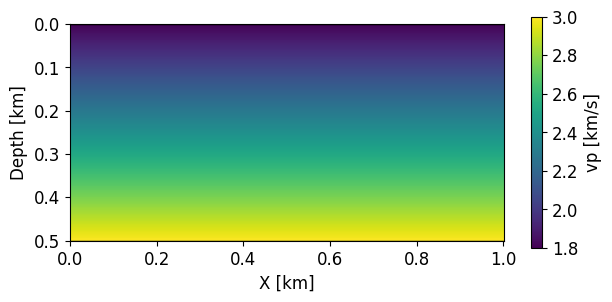

In [3]:
model.plot("vp", figsize=(7, 3), aspect="equal")


## Inspect Sampled Property Profiles

`sample_uniform(...)` returns ordinary `xarray` data. Here the center trace through the sampled model confirms that `Vp`, `Vs`, and `Rho` were interpreted with the intended units and depth trend before the model is sent to the solver.


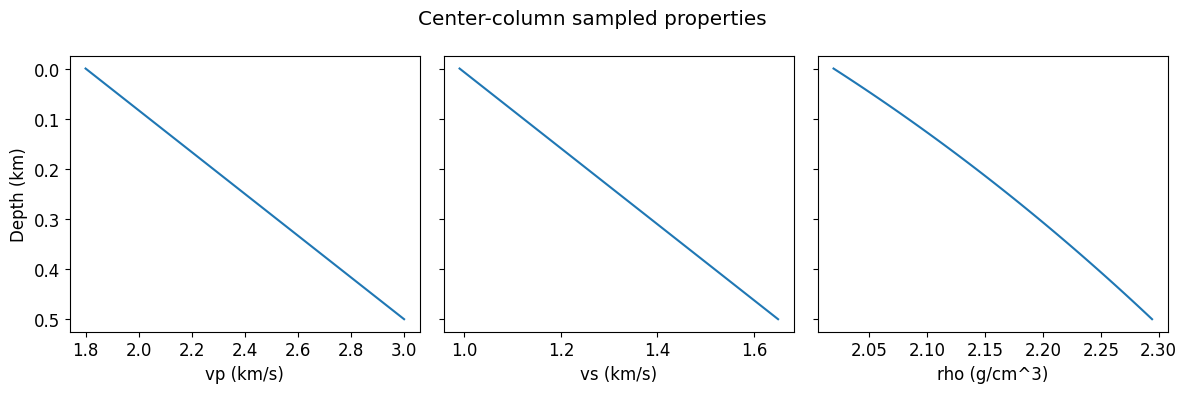

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
center_x = sampled.x.size // 2
for ax, name in zip(axes, ["vp", "vs", "rho"]):
    profile = sampled[name].isel(x=center_x)
    ax.plot(profile.values, sampled.z.values)
    ax.invert_yaxis()
    ax.set_xlabel(f"{name} ({profile.attrs.get('units', '')})")
axes[0].set_ylabel("Depth (km)")
fig.suptitle("Center-column sampled properties")
fig.tight_layout()


## Run A Small Elastic Job

The result demonstrates that variable properties are not just visualization inputs: the same `xarray` definitions are exported as material properties for the solver. The receiver line records vertical velocity through the depth-gradient model.


In [ ]:
sim += model.hex_mesh_generator([8, 4])
sim.mesh.set_adapt(elems_per_wave=2.0, order=4, f_low=5.0, f_high=30.0)
sim += fs.BoundaryCondition(conditions=["free"], boundaries=["z_min"])
sim += fs.BoundaryCondition(conditions=["pml"], boundaries=["x_min", "x_max", "z_max"], pml_wavelengths=0.75)

acq = fs.Acquisition()
acq.add_sources(kind="vector", coords=[[0.5, 0.05]], direction=[0.0, 1.0])
receiver = fs.ReceiverNode(name="geophone")
receiver.add_component(name="v_z", field="velocity", direction=[0.0, 1.0])
receiver_coords = [[x, 0.04] for x in np.linspace(0.1, 0.9, 61)]
acq.add_receiver_group(name="surface", device=receiver, coords=receiver_coords)
sim += acq
sim += fs.Discretization()
sim += fs.SolverConfig(tolerance=1.0e-4, grids=3)

site = fs.LocalSite(shutdown_on_completion=True, verbose=True)
job = fs.TimeDomainJob(
    name="time_variable_properties",
    simulation=sim,
    f_min=0.0,
    f_max=30.0,
    T_max=0.9,
)
result = site.submit(job).wait()
traces = result.traces(upscale=4)
traces.summary


RuntimeError: Mesh task failed: Command '['/Users/jacobbadger/omnirepo/FS_solver/FS_seismic', '-nthreads', '1', '-j', '/Users/jacobbadger/omnirepo/FrequenSolve/examples/tutorials/03_velocity_model_building/scratch/tutorials/variable_properties/jobs/variable_properties/time_variable_properties/time_variable_properties.json', '--mesh']' returned non-zero exit status 1.. Log: /Users/jacobbadger/omnirepo/FrequenSolve/examples/tutorials/03_velocity_model_building/scratch/tutorials/variable_properties/jobs/variable_properties/time_variable_properties/logs/mesh.log

: 

## Plot The Variable-Property Response

The trace gather is a quick end-to-end check: the variable-property model was sampled, exported, solved, and read back through the trace API.


In [ ]:
wavelet = fs.RickerWavelet(f=12.0)
group = traces.groups[0]
component = traces.components(group)[0]
source = traces.sources(group)[0]
gather = traces.td(group, component, source, wavelet, upscale=4, T_max=0.9)
fs.plot_gather(
    gather,
    A=2.0 * np.nanstd(np.real(gather.values)),
    cmap="gray",
    figsize=(9, 4),
    title="Variable-property elastic response",
)


## Before Moving On

The main user risk is unit ambiguity. Check coordinate units and property units before submission, then verify sampled profiles are plausible in the simulation coordinate system. The solver will see exported material properties, but the notebook author should reason about them as physical quantities first.

After this tutorial, variable properties should feel like a controlled extension of layered modeling, not a separate modeling system.

## Result Review Checklist

Variable-property models should be checked before and after execution. The sampled model is the authoring-side proof; the trace gather is the solver-side proof.

| Artifact | What to confirm |
| --- | --- |
| `xarray` attrs | Coordinate arrays and property arrays both carry units. |
| Center-column profiles | `Vp`, `Vs`, and `Rho` vary with depth as intended and stay in plausible ranges. |
| Exported simulation | The model is still represented as material properties, not just as a plotting object. |
| Trace gather | The run used the variable model and returned ordinary `TraceDataset` output. |

If a variable property appears constant after export, inspect dimension names, coordinate units, and whether the property array coordinates overlap the model bounds.
